#STEP 1: LOAD AND INSPECT DATA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('netflix_titles.csv')

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Netflix dataset was loaded into a Pandas DataFrame using the read_csv() function

In [ ]:
df.shape

(8807, 12)

The shape consists of
(rows, columns) i.e.
8807 rows and
12 columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


df.info() tells us column names,
number of non-null values and
data type of each column.

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


df.isnull().sum()
counts Missing values in each column.

In [ ]:
df.duplicated().sum()

np.int64(0)

df.duplicated().sum() checks whether duplicate rows exist.

# **The 5-Line Summary**

* The dataset provides information about movies and TV shows available on Netflix.
* It includes details such as title, director, cast, country, release year, rating, and duration.
* The data contains both categorical attributes (e.g., type, rating, country) and numerical attributes (e.g., release year).
* Columns like director, cast, country, and date_added, contain missing values require some cleaning.
* This dataset can be used to analyze trends, country-wise contributions, ratings distribution, and the growth of Netflix.


#STEP 2: Data Cleaning

In [ ]:
df.drop_duplicates(inplace=True)

Removed the Duplicate values using above function.

In [ ]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

The fillna() is used to fill in missing values of Director, Country and Cast with value as Unknown.

In [ ]:
df_original = pd.read_csv('netflix_titles.csv')

print(df_original.loc[
    [6066,6174,6795,6806,6901,7196,7254,7406,7847,8182],
    'date_added'
])

6066    NaN
6174    NaN
6795    NaN
6806    NaN
6901    NaN
7196    NaN
7254    NaN
7406    NaN
7847    NaN
8182    NaN
Name: date_added, dtype: object


In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', errors='coerce')

In [ ]:
print(df['date_added'].dtype)
df['year_added'] = df['date_added'].dt.year

datetime64[ns]


The date_added column was converted from string format to datetime format using pd.to_datetime().

And then created "year_added" column and year value was extracted and stored in a new column.

In [ ]:
df.drop(columns=['description'], inplace=True)

The df.drop(columns) removed Description column as it was
not needed for current analysis.

## **Reasons of Cleaning**
1. Removed duplicates to **prevent** **duplicate** **records** from affecting analysis.

2. Filled missing **cast**, **country** and **director** values with "**Unknown**" to	maintain dataset **completeness**.

4. Converted **date_added** to datetime	and then created **year_added** column that	helps **analyze** content **growth**.

7. Removed **description** column	as it was **not** **needed** for current analysis.




#STEP 3: EDA

**Q1. What is the proportion of Movies and TV Shows available on Netflix?**

In [ ]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


**Q2. Which countries produce the most Netflix content? (Top 10)**

In [ ]:
df['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


**Q3. What are the most frequently assigned content ratings on Netflix?**

In [ ]:
df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


**Q4.How many titles were added each year?**

In [ ]:
df.groupby('year_added')['show_id'].count().sort_index()

,show_id
year_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,11
2014.0,24
2015.0,82
2016.0,429


**Q5. Which directors have the most titles on Netflix? (Top 5)**

In [ ]:
df['director'].value_counts().head(5)

,count
director,
Unknown,2634
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16


#Step 4: Visualizations

**1. BAR CHART - Top Countries**

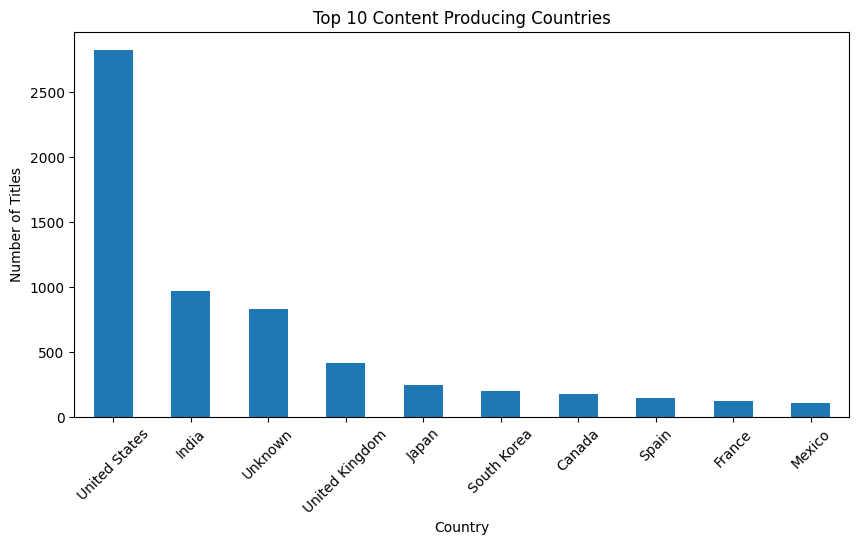

In [ ]:
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')
plt.title('Top 10 Content Producing Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

The bar chart shows that the **United States** has the **highest number of titles** on Netflix. Most of the content available on Netflix comes from the USA.
And **Mexico** contributes the lowest titles.

**2. PIE CHART- Movies vs TV Shows**

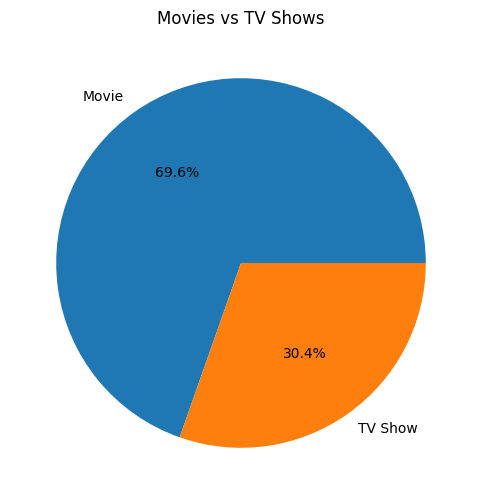

In [ ]:
df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6) )
plt.title('Movies vs TV Shows')
plt.ylabel('')
plt.show()

The pie chart shows that Netflix has **more movies (69.6%)** than TV shows. This means Netflix focuses more on providing movie content.

**3. Line Chart – Content Added by Year**

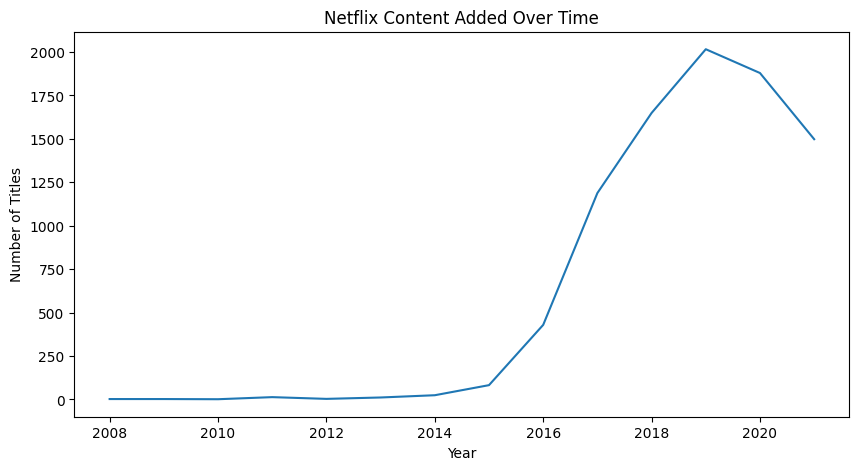

In [ ]:
yearly_content = df.groupby('year_added')['show_id'].count()
plt.figure(figsize=(10,5))
plt.plot(yearly_content.index, yearly_content.values)
plt.title('Netflix Content Added Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

The line chart shows that the number of titles added to Netflix **increased a lot after 2015**.

**4. Histogram – Movie Duration Distribution**

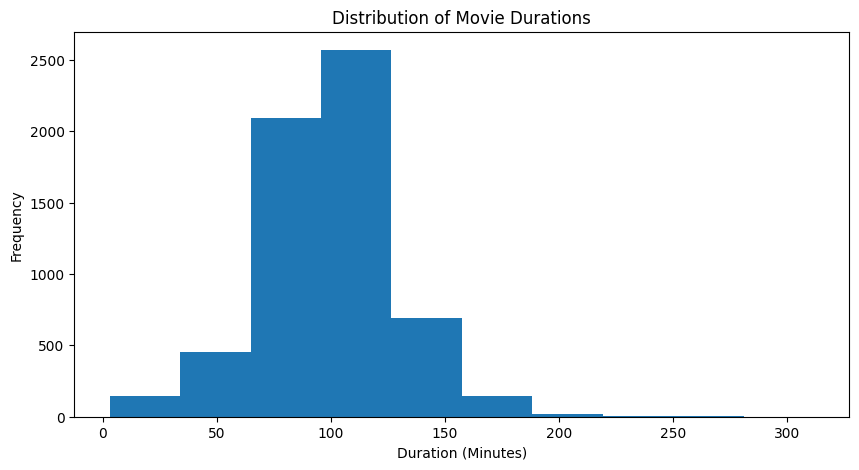

In [ ]:
movies = df[df['type']=='Movie'].copy()
movies.dropna(subset=['duration'], inplace=True)
movies['duration_num'] = movies['duration'].str.replace(' min','').astype(int)

plt.figure(figsize=(10,5))
plt.hist(movies['duration_num'], bins=10)

plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Frequency')
plt.show()

Most Netflix movies fall within the 80–120 minute range, indicating a preference for standard feature-length films.

**5. Scatter Plot - Release Year vs Year Added**

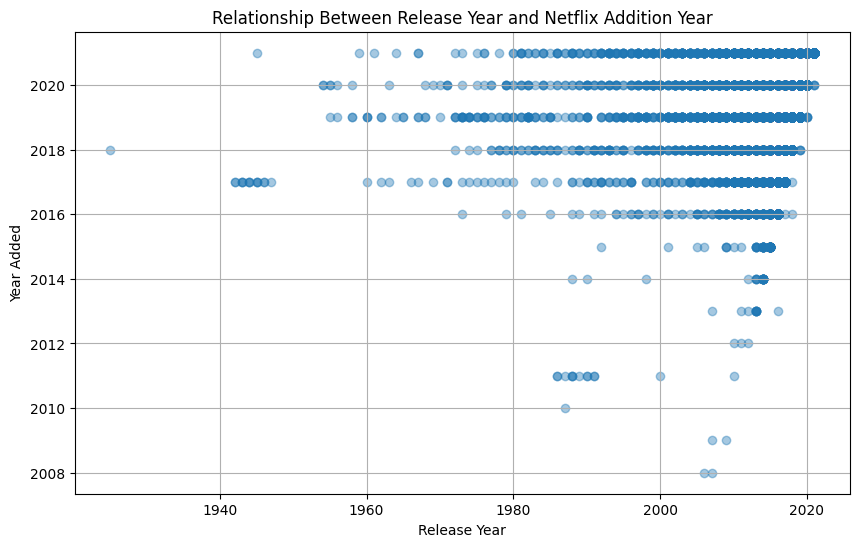

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['release_year'],
    df['year_added'],
    alpha=0.4
)

plt.title('Relationship Between Release Year and Netflix Addition Year')
plt.xlabel('Release Year')
plt.ylabel('Year Added')

plt.grid(True)

plt.show()

The scatter plot shows that most of the content added to Netflix consists of recently released movies and TV shows. This suggests that Netflix mainly focuses on providing **newer content**.

**6. Heatmap- Missing Values**

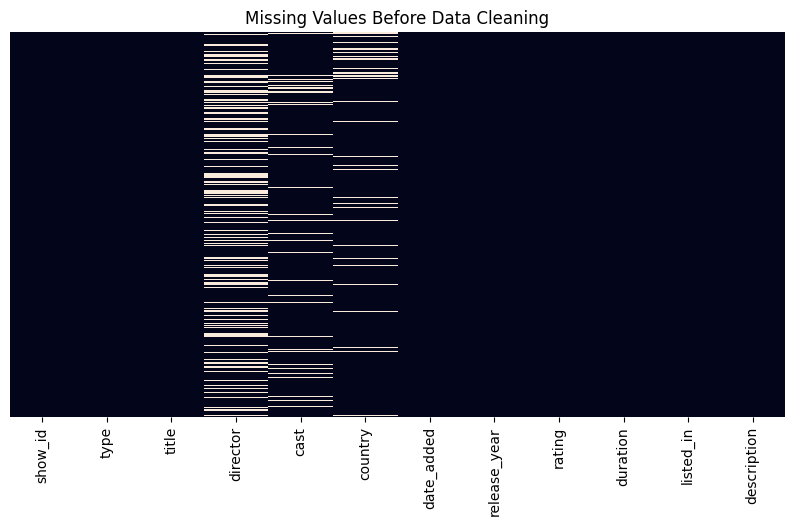

In [ ]:
df_uncleaned = pd.read_csv('netflix_titles.csv')

plt.figure(figsize=(10,5))

sns.heatmap(
    df_uncleaned.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title('Missing Values Before Data Cleaning')
plt.show()

The missing values heatmap shows that the director, cast, and country columns contain the highest number of missing entries.

This indicates that information for some Netflix titles is incomplete and required preprocessing before data cleaning was performed.

# STEP 5: INSIGHTS REPORT

# Insights Report

**1. The United States has the most Netflix content.**

The **bar chart** shows that the United States contributes the highest number of movies and TV shows on Netflix. This means Netflix depends heavily on content produced in the U.S.



**2. Movies are more common than TV Shows on Netflix.**

The **pie chart** shows that movies make up a larger part of the Netflix catalog than TV shows. This suggests that Netflix offers more movie content to its viewers.


**3. Netflix added a lot more content after 2015.**

The **line chart** shows a sharp increase in the number of titles added after 2015. This indicates that Netflix expanded its content library rapidly during those years.



**4. Most Netflix movies are around 80–120 minutes long.**

The **histogram** shows that most movies fall within the 80 to 120-minute range. This means Netflix mainly features standard-length movies rather than very short or very long ones.



**5. Some important information was missing in the dataset.**

The **heatmap** showed missing values in columns such as director, cast, and country before cleaning. These missing values had to be handled to make the analysis more accurate.

# **Finding That Surprised Me the Most**

The most surprising finding was **how quickly Netflix's content library grew after 2015**.

The number of titles added increased drastically, showing how rapidly Netflix expanded its platform in a short period of time.